# CIFAR-10 Convolutional Neural Network (CNN) implementation

This document contains the implementation of a Convolutional Neural Network (CNN) for classifying images from the CIFAR-10 dataset. The CIFAR-10 dataset consists of 60,000 32x32 color images in 10 classes, with 6,000 images per class. The CNN architecture will be designed to process the spatial structure of the images and output class probabilities. At hte end of the document we will evaluate the model and compare its performance to a fully connected network (FCN) that we built earlier.

In [36]:
import warnings
# Suppress NumPy 2.4 deprecation warning from Keras pickle loading
warnings.filterwarnings("ignore", message=".*align should be passed as Python or NumPy boolean.*")

In [37]:
# imports
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers

import numpy as np
import matplotlib.pyplot as plt

from keras.datasets import cifar10
from keras.regularizers import l2

from keras import backend as K
print(K.backend())

tensorflow


## Loading the CIFAR-10 dataset

The dataset is loaded using the `cifar10.load_data()` function, which returns the training and testing data. The training data consists of 50,000 images and their corresponding labels, while the testing data consists of 10,000 images and their corresponding labels. Each image is a 32x32 pixel color image with three channels (RGB), and each label is an integer representing the class of the image. The classes in the CIFAR-10 dataset are:
- 0: airplane
- 1: automobile
- 2: bird
- 3: cat
- 4: deer
- 5: dog
- 6: frog
- 7: horse
- 8: ship
- 9: truck

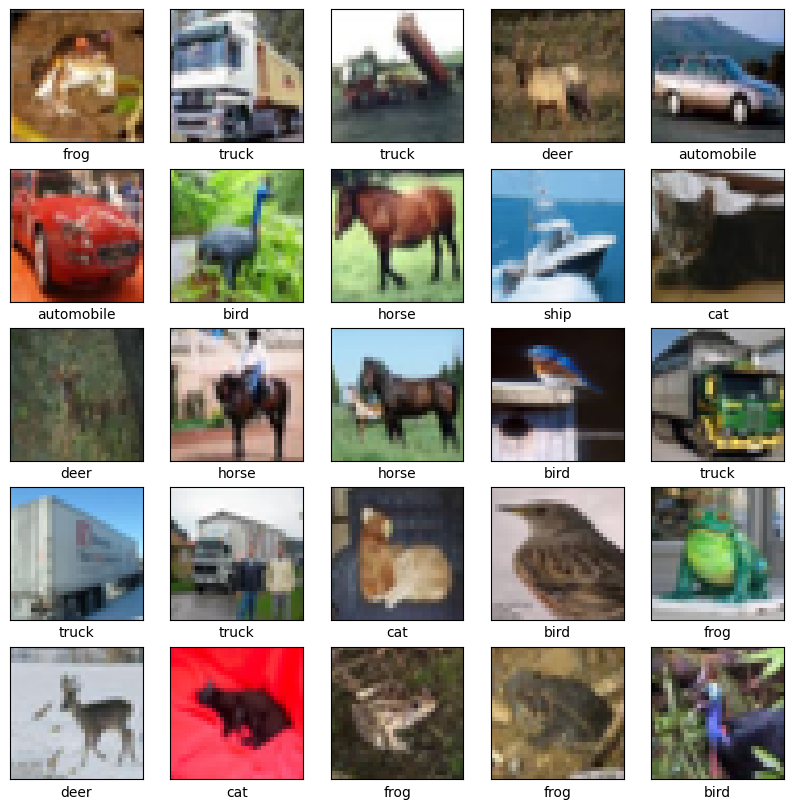

In [38]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.xlabel(class_names[y_train[i][0]])
plt.show()

## Preparing the data

Before training the model, we need to preprocess the data. The pixel values of the images are normalized to the range [0, 1] by dividing by 255. Additionally, the labels are converted to one-hot encoded vectors using `keras.utils.to_categorical()`, which is necessary for multi-class classification with categorical cross-entropy loss.

In [39]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

print("x_train shape:", x_train.shape)

x_train shape: (50000, 32, 32, 3)


Before we build the CNN architecture, let's define some hyperparameters that will control the training process and the model's complexity. These include:
- `weight_decay`: A small penalty applied to large weights to prevent overfitting. This encourages the model to learn simpler patterns that generalize better to unseen data.
- `batch_size`: The number of images the model sees before updating its weights. A larger batch size can lead to faster training but may require more memory, while a smaller batch size can lead to more stable updates but may take longer to train.
- `epochs`: The number of times the model will go through the entire dataset during training. More epochs can lead to better performance, but also increases the risk of overfitting if the model starts to memorize the training data instead of learning general patterns.

In [40]:
# Hyperparameters
weight_decay = 0.0001   # Small penalty applied to large weights to prevent overfitting
batch_size   = 64       # Number of images the model sees before updating its weights
epochs       = 19       # How many times the model will go through the entire dataset

## Building the Convolutional Neural Network (CNN)

- We start by defining the input layer, which specifies the shape of the input images (32x32 pixels with 3 color channels).
- Next, we apply data augmentation layers that randomly rotate and zoom the images during training. This helps the model learn to recognize objects in different orientations and scales, improving its generalization.
- The CNN is structured in three blocks, each designed to learn different levels of features:
  - Block 1: Learns basic features like edges and colors using 32 filters.
  - Block 2: Learns intermediate features like shapes and textures using 64 filters.
  - Block 3: Learns high-level features like object parts using 128 filters.
- Each block consists of two convolutional layers followed by batch normalization, max pooling, and dropout to reduce overfitting.
- - Convolutional layers use small 3x3 filters to scan the image and detect patterns. The 'padding=same' argument ensures that the output feature maps have the same spatial dimensions as the input, allowing for deeper networks without shrinking the feature maps too quickly.
- - Batch normalization normalizes the outputs of the convolutional layers, which helps stabilize and speed up training by keeping the activations on a similar scale.
- - Max pooling reduces the spatial dimensions of the feature maps by taking the maximum value in each 2x2 area, which helps reduce computation and forces the model to focus on the most important features.
- - Dropout randomly switches off a fraction of the neurons during training, which helps prevent the model from overfitting by encouraging it to learn more robust features that are not reliant on any single neuron.
- Finally, the output layer uses a softmax activation function to produce probabilities for each of the 10 classes in the CIFAR-10 dataset.

In [41]:
# Input
# Tell the model what shape each image comes in: 32x32 pixels, 3 color channels (RGB)
inputs = keras.Input(shape=(32, 32, 3))

# Data augmentation
x = layers.RandomRotation(0.1)(inputs) # Connect to inputs instead of undefined x
x = layers.RandomZoom(0.1)(x)          # slight zoom, teaches scale invariance


# Block 1 Learn basic features like edges and colors
# Scan the image with 32 small 3x3 filters to detect simple patterns like edges and corners
# 'padding=same' keeps the output the same width/height as the input
# L2 regularization quietly discourages the filters from becoming too extreme
x = layers.Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay))(x)
# Normalize the outputs so every filter's results are on a similar scale. This keeps training stable
x = layers.BatchNormalization()(x)

# A second round of 32 filters so the model can combine the simple patterns it just found
x = layers.Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay))(x)
x = layers.BatchNormalization()(x)

# Shrink the image by half (take the brightest value in each 2x2 area)
# This reduces computation and forces the model to keep only the strongest signals
x = layers.MaxPooling2D(pool_size=(2, 2))(x)
# Randomly switch off 20% of neurons during training so the model doesn't just memorize the data
x = layers.Dropout(0.2)(x)


# Block 2 Learn intermediate features like shapes and textures
# Double the number of filters to 64. Now the model can detect more complex combinations of edges
x = layers.Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay))(x)
x = layers.BatchNormalization()(x)

x = layers.Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay))(x)
x = layers.BatchNormalization()(x)

x = layers.MaxPooling2D(pool_size=(2, 2))(x)
# Slightly higher dropout (30%) because the model is getting more powerful and more risk of overfitting
x = layers.Dropout(0.3)(x)


# Block 3 Learn high-level features like object parts
# 128 filters at this depth the model starts recognizing things like wheels, eyes, or wings
x = layers.Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay))(x)
x = layers.BatchNormalization()(x)

x = layers.Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay))(x)
x = layers.BatchNormalization()(x)

x = layers.MaxPooling2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.4)(x)

# Output
# Unroll the 3-D feature map into a flat list of numbers so the Dense layer can read it
x = layers.Flatten()(x)
# One output neuron per class (10 classes in CIFAR-10).
# Softmax turns raw scores into probabilities that add up to 100%, e.g. "70% dog, 20% cat …"
outputs = layers.Dense(10, activation='softmax')(x)

# Assemble & summarise
model = keras.Model(inputs=inputs, outputs=outputs, name="cifar10_cnn")
model.summary()

Model: "cifar10_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_3               │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_3 (RandomZoom)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 309,290 (1.18 MB)

 Trainable params: 308,394 (1.18 MB)

 Non-trainable params: 896 (3.50 KB)

Total trainable parameters come up to 308,394, which is significantly fewer than the 3.8 million parameters in the fully connected network (FCN) we built earlier. This is because CNNs share weights across spatial locations, allowing them to learn more efficiently from image data while also reducing the risk of overfitting. The convolutional layers learn local patterns that are relevant across the entire image, which is why they can achieve good performance with fewer parameters compared to fully connected layers that treat each pixel independently.

In [42]:
model.compile(
    # Categorical cross-entropy measures how wrong the probability predictions are for multi-class problems.
    loss="categorical_crossentropy",
    # Adam automatically adjusts the learning rate - a safe, popular default.
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

## Training the model

The model is trained for 19 epochs with a batch size of 64. During training, 20% of the training data is used for validation to monitor the model's performance on unseen data. The training history, including loss and accuracy for both training and validation sets, is stored in the `history` variable.

In [43]:
history = model.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    # Hold back 20% of training data to check performance on unseen examples after each epoch.
    validation_split=0.2,
)

Epoch 1/19
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.3812 - loss: 2.0773 - val_accuracy: 0.4417 - val_loss: 1.6601
Epoch 2/19
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.4928 - loss: 1.5907 - val_accuracy: 0.5365 - val_loss: 1.4885
Epoch 3/19
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.5533 - loss: 1.3966 - val_accuracy: 0.5895 - val_loss: 1.3292
Epoch 4/19
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.5923 - loss: 1.2394 - val_accuracy: 0.5148 - val_loss: 1.8774
Epoch 5/19
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.6302 - loss: 1.1237 - val_accuracy: 0.6279 - val_loss: 1.1556
Epoch 6/19
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.6557 - loss: 1.0540 - val_accuracy: 0.6838 - val_loss: 1.0076
Epoch 7/19
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.6766 - loss: 0.9915 - val_accuracy: 0.6751 - val_loss: 1.0328
Epoch 8/19
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.6934 - loss: 0.9568 - 

The training process takes exponentially more time compared to the fully connected network (FCN) due to the increased complexity of the model. Even though the CNN has fewer parameters than the FCN, the convolutional layers require more computations to process the spatial structure of the images. Each convolutional layer applies multiple filters across the entire image, which involves a large number of multiplications and additions. Additionally, the data augmentation layers introduce extra overhead during training as they generate new variations of the input images on-the-fly. As a result, while the CNN is more powerful and better suited for image classification tasks, it also demands significantly more computational resources and time to train effectively compared to a simpler FCN architecture.

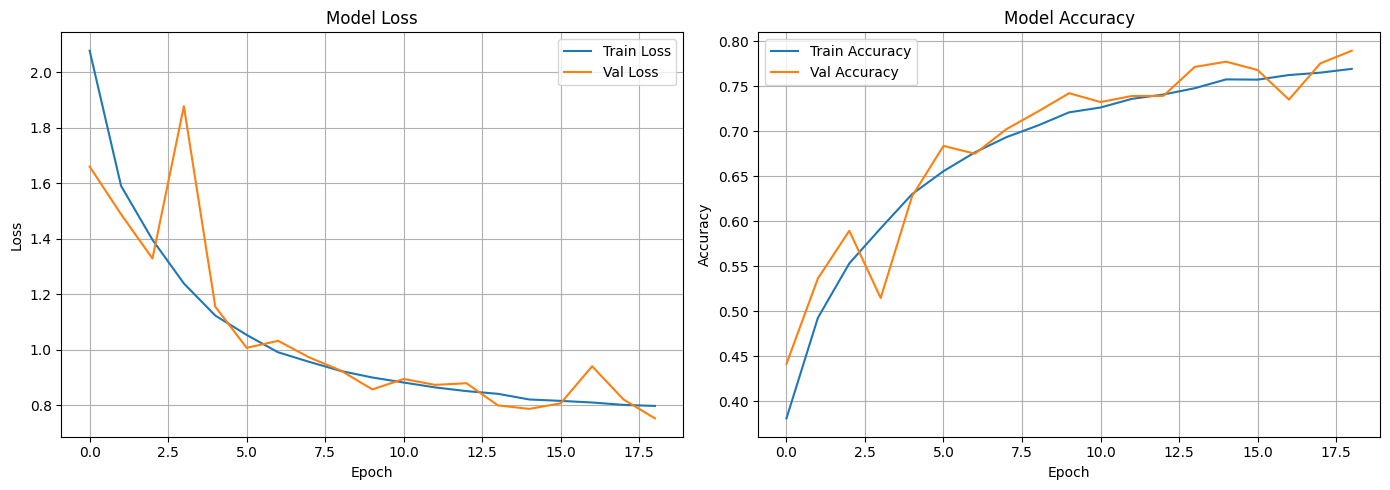

313/313 - 1s - 4ms/step - accuracy: 0.7815 - loss: 0.7751

Test accuracy: 0.7815
Test loss: 0.7751


In [44]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axs[0].plot(history.history["loss"], label="Train Loss")
axs[0].plot(history.history["val_loss"], label="Val Loss")
axs[0].set_title("Model Loss")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].legend()
axs[0].grid(True)

# Accuracy plot
axs[1].plot(history.history["accuracy"], label="Train Accuracy")
axs[1].plot(history.history["val_accuracy"], label="Val Accuracy")
axs[1].set_title("Model Accuracy")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Accuracy")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

# Evaluate and print test results
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

The training and validation loss curves show that the model is learning effectively, with both losses decreasing over time. The slight zig-zagging at the end of the validation loss curve is likely due to the Adam optimizer's adaptive learning rate, which can cause more fluctuations in the loss values compared to a more stable optimizer like SGD. Overall, the model seems to be converging well, and the use of data augmentation and dropout has likely helped to prevent overfitting, as evidenced by the relatively smooth validation loss curve.

## Evaluating the model

Next we will look at the test set performance of the model, which will give us an indication of how well the model generalizes to unseen data. The test loss and accuracy will provide insights into the model's ability to classify new images correctly.

In [45]:
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.7750809788703918
Test accuracy: 0.781499981880188


The model achieves a test accuracy of around 78% which is much better than the 56% accuracy achieved by the fully connected network (FCN) on the same dataset. This significant improvement can be attributed to the CNN's ability to learn spatial hierarchies of features, which is crucial for image classification tasks. The convolutional layers in the CNN are designed to capture local patterns such as edges, textures, and shapes, which are essential for distinguishing between different classes in the CIFAR-10 dataset. Additionally, the use of data augmentation and dropout has likely contributed to better generalization, allowing the model to perform well on unseen test data. Overall, the CNN's architecture and training strategies have enabled it to achieve a much higher accuracy compared to the FCN.

Now we can take a look at some of the predictions made by the model on the test set. We will visualize a few test images along with their true labels and the predicted probabilities for each class. This will help us understand how well the model is performing on individual examples and identify any potential misclassifications.

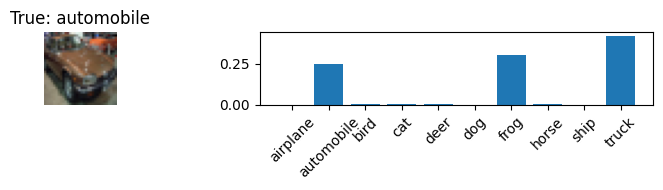

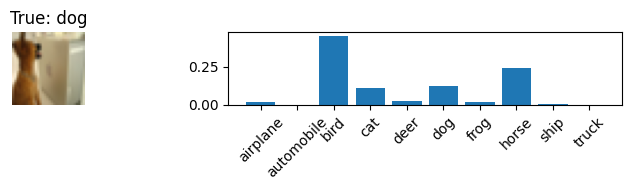

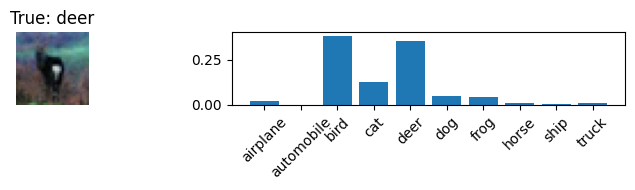

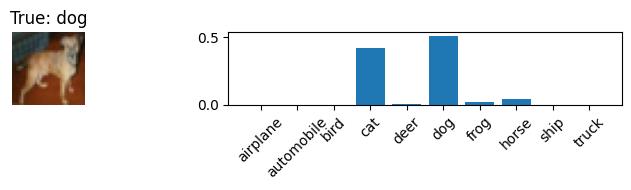

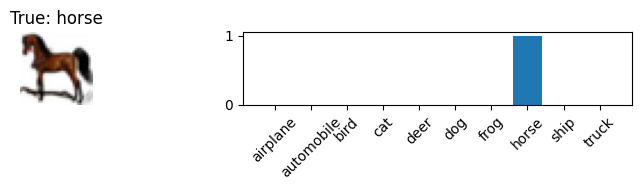

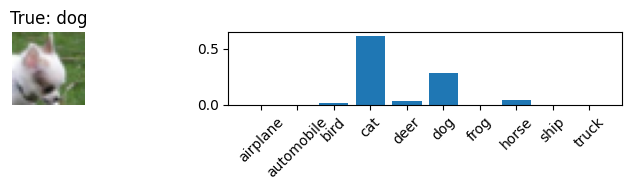

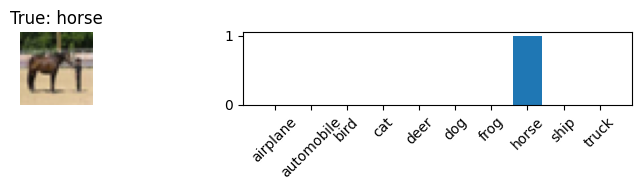

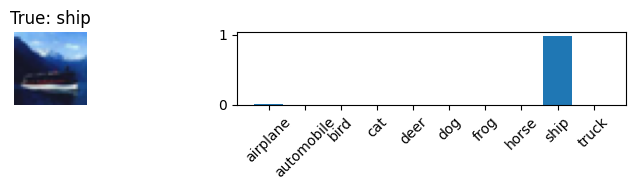

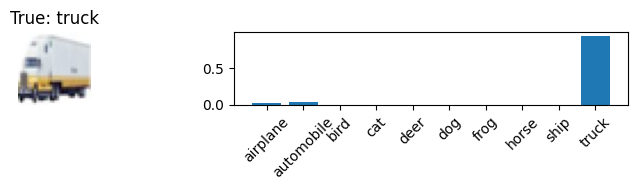

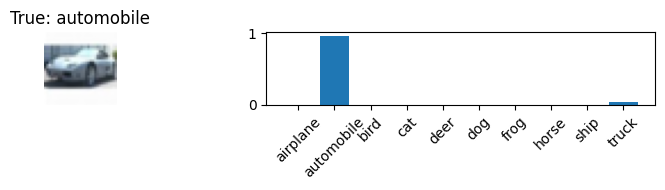

In [46]:
x = x_test
y = model(x)
start = 2000

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

for k in range(10):
    plt.figure(figsize=(8, 2))
    plt.subplot(1, 2, 1)
    plt.title(f"True: {class_names[np.argmax(y_test[start+k])]}")
    plt.imshow(x[start + k].reshape((32, 32, 3)))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    ind = np.arange(10)
    plt.bar(ind, y[start + k].numpy().flatten())

    plt.xticks(ind, class_names, rotation=45)
    plt.tight_layout()
    plt.show()

On these specific examples, the model seems to be making mostly correct predictions. There are however a few cases where the model is confused and fails to predict correctly. For instance on the first image, the model predicts a truck but the correct label is automobile. This could be due to the fact that trucks and automobiles can have similar shapes and features, making it difficult for the model to distinguish between them. When examining the predictions further we can see that the model strugles more with distinguishing different animals from each other, such as cats and dogs, which is a common challenge in image classification tasks. Overall, while the model performs well on many examples, there are still some misclassifications that highlight areas where the model could be improved, such as by adding more training data or using more advanced architectures. Compared to the FCN, the CNN is much better at capturing the spatial features of the images, which is why it achieves higher accuracy and makes more accurate predictions on the test set.